In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Anemia_Data_With_Risk_Score.xlsx")
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Dataset shape: (706, 18)


,District,State,Women_Literacy,Women_Schooling,Teenage_Pregnancy,IFA_Consumption,Institutional_Births,Low_BMI,Improved_Sanitation,Clean_Cooking_Fuel,Health_Insurance,Women_Anemia,Children_Anemia,NonPregnant_Anemia,Pregnant_Anemia,Teen_Women_Anemia,Risk Score,Risk Category
0,Nicobars,Andaman & Nicobar Islands,87.5,53.5,1.8,72.6,97.8,8.2,83.5,56.9,2.7,38.3,37.7,38.4,51.9,48.0,23.505,Low
1,North & Middle Andaman,Andaman & Nicobar Islands,84.0,41.0,3.8,83.7,97.7,8.6,86.4,61.3,2.1,62.1,30.4,62.5,51.9,47.8,30.340,Moderate
2,South Andaman,Andaman & Nicobar Islands,86.7,57.5,2.8,81.0,99.5,10.0,89.3,91.9,1.2,57.7,43.4,57.6,51.9,43.2,28.645,Moderate
3,Srikakulam,Andhra Pradesh,64.3,42.5,5.5,67.5,97.9,13.8,71.6,74.7,75.6,62.6,59.6,62.8,51.9,59.2,39.160,Moderate
4,Vizianagaram,Andhra Pradesh,58.3,37.6,12.7,59.6,99.0,16.9,61.7,60.3,76.7,64.0,66.7,64.6,51.9,73.9,43.840,Moderate


**Overall Anemia Prevalence**

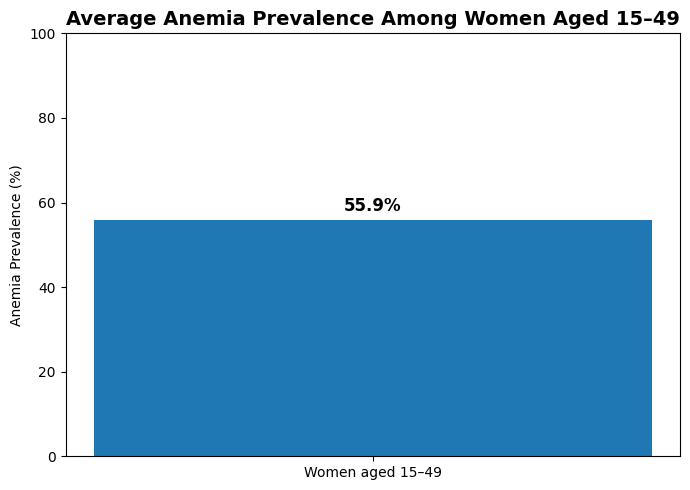

In [2]:
anemia_col = "Women_Anemia"
average_anemia = df[anemia_col].mean()
plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Women aged 15–49"],
    [average_anemia]
)

plt.title(
    "Average Anemia Prevalence Among Women Aged 15–49",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Anemia Prevalence (%)")
plt.ylim(0, 100)

plt.text(
    0,
    average_anemia + 2,
    f"{average_anemia:.1f}%",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Top 10 States by Anemia Prevalence**

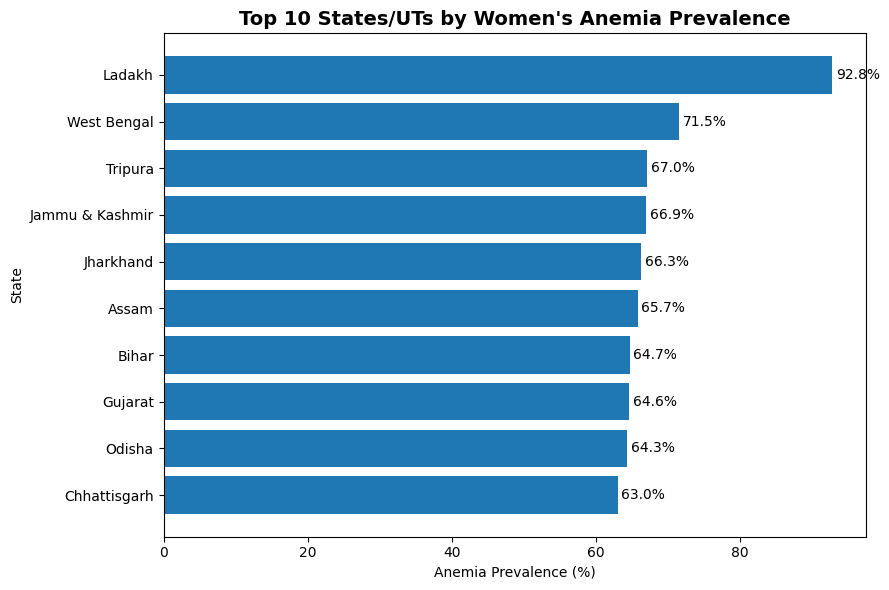

In [3]:
state_anemia = (
    df.groupby("State")[anemia_col]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)
plt.figure(figsize=(9,6))
bars = plt.barh(
    state_anemia.index,
    state_anemia.values
)
plt.title(
    "Top 10 States/UTs by Women's Anemia Prevalence",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Anemia Prevalence (%)")
plt.ylabel("State")
for bar, value in zip(bars, state_anemia.values):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center"
    )
plt.tight_layout()
plt.show()

**Top 10 Districts with Highest Anemia**

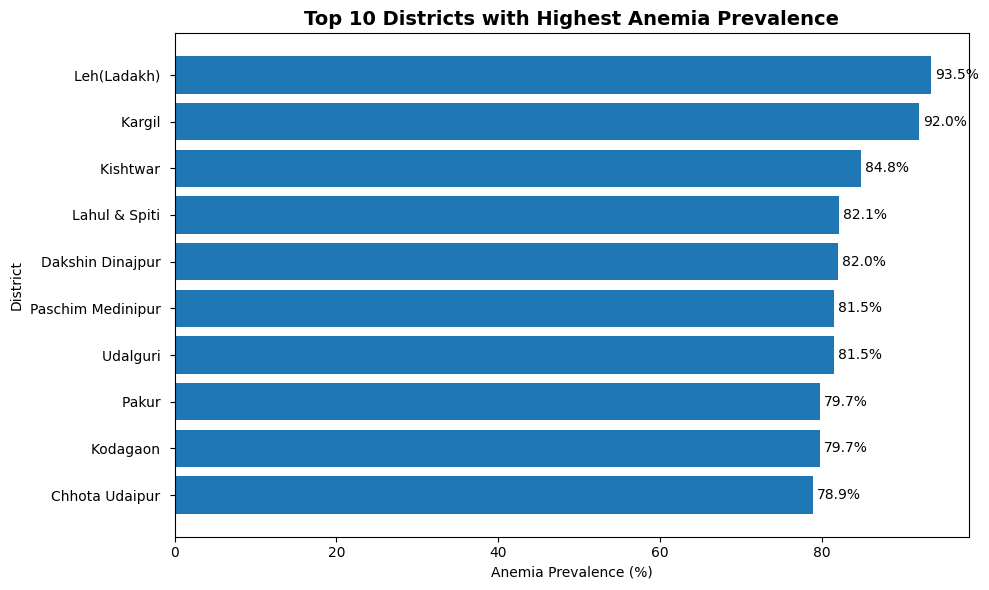

In [4]:
top_districts = (
    df[
        ["District", "State", anemia_col]
    ]
    .sort_values(
        by=anemia_col,
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_districts["District"][::-1],
    top_districts[anemia_col][::-1]
)

plt.title(
    "Top 10 Districts with Highest Anemia Prevalence",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Anemia Prevalence (%)")
plt.ylabel("District")

for bar, value in zip(
    bars,
    top_districts[anemia_col][::-1]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Correlation Heatmap**

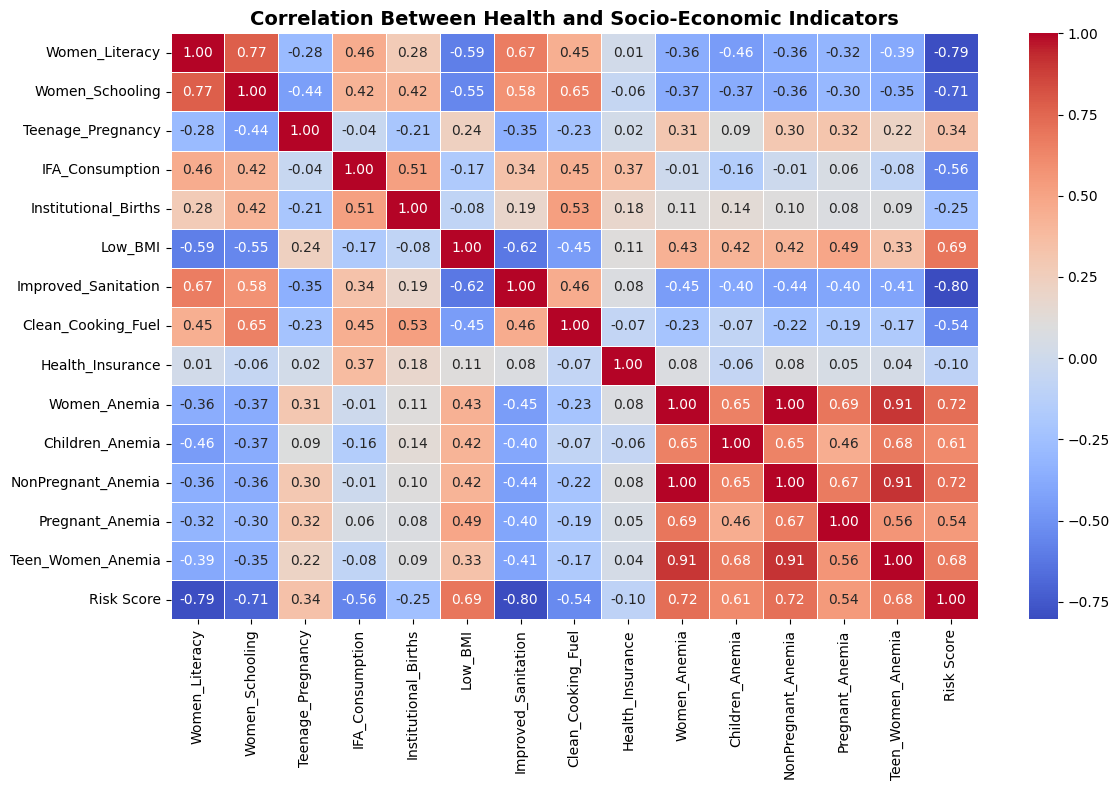

In [5]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title(
    "Correlation Between Health and Socio-Economic Indicators",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

**Risk Score vs Anemia**

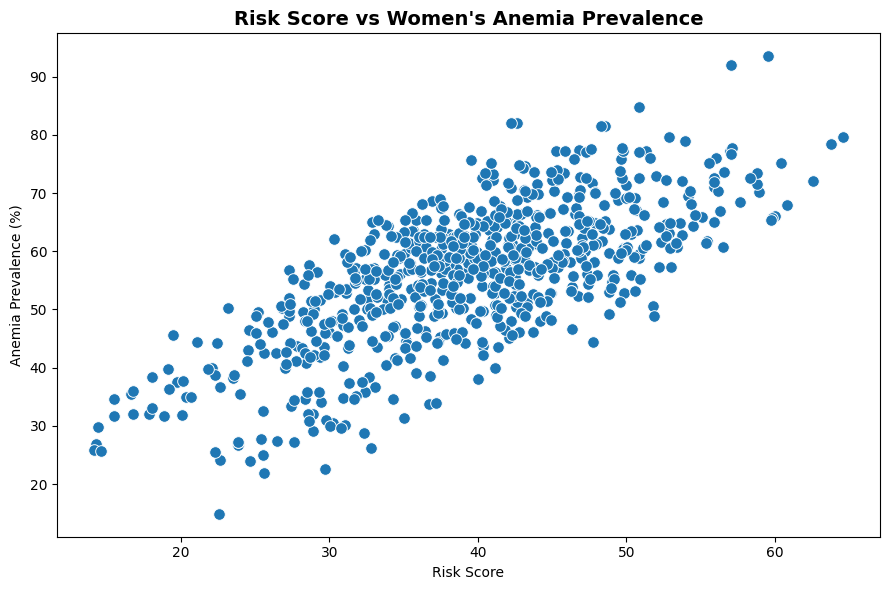

In [6]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Risk Score",
    y=anemia_col,
    s=70
)
plt.title(
    "Risk Score vs Women's Anemia Prevalence",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Risk Score")
plt.ylabel("Anemia Prevalence (%)")
plt.tight_layout()
plt.show()

**Risk Category Distribution**

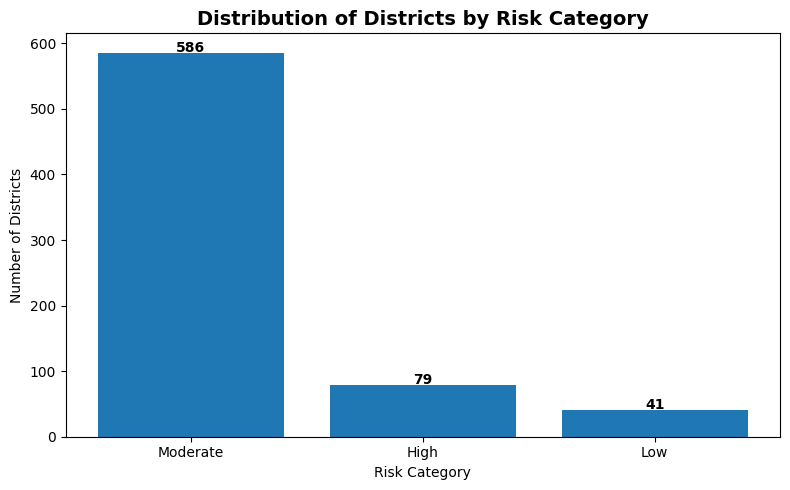

In [7]:
risk_counts = df["Risk Category"].value_counts()
plt.figure(figsize=(8,5))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values
)
plt.title(
    "Distribution of Districts by Risk Category",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Risk Category")
plt.ylabel("Number of Districts")
for bar, value in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        str(value),
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()